[*********************100%***********************]  13 of 13 completed
<ipython-input-2-1715228967>:14: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = df.pct_change().dropna()


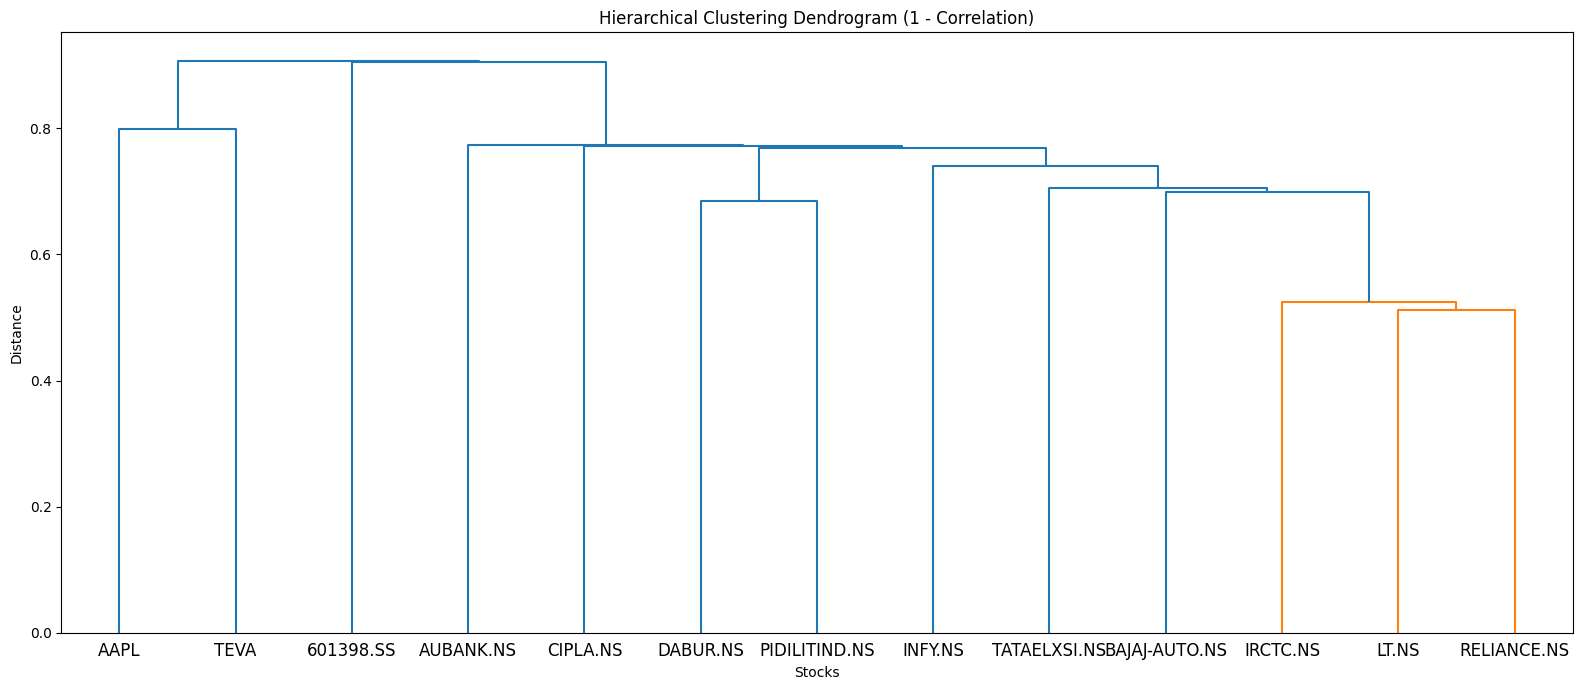

Streaming output truncated to the last 5000 lines.
<ipython-input-2-1715228967>:54: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return float(np.dot(w.T, np.dot(cov1, w)))
<ipython-input-2-1715228967>:54: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return float(np.dot(w.T, np.dot(cov1, w)))
<ipython-input-2-1715228967>:54: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return float(np.dot(w.T, np.dot(cov1, w)))
<ipython-input-2-1715228967>:54: DeprecationWarning:

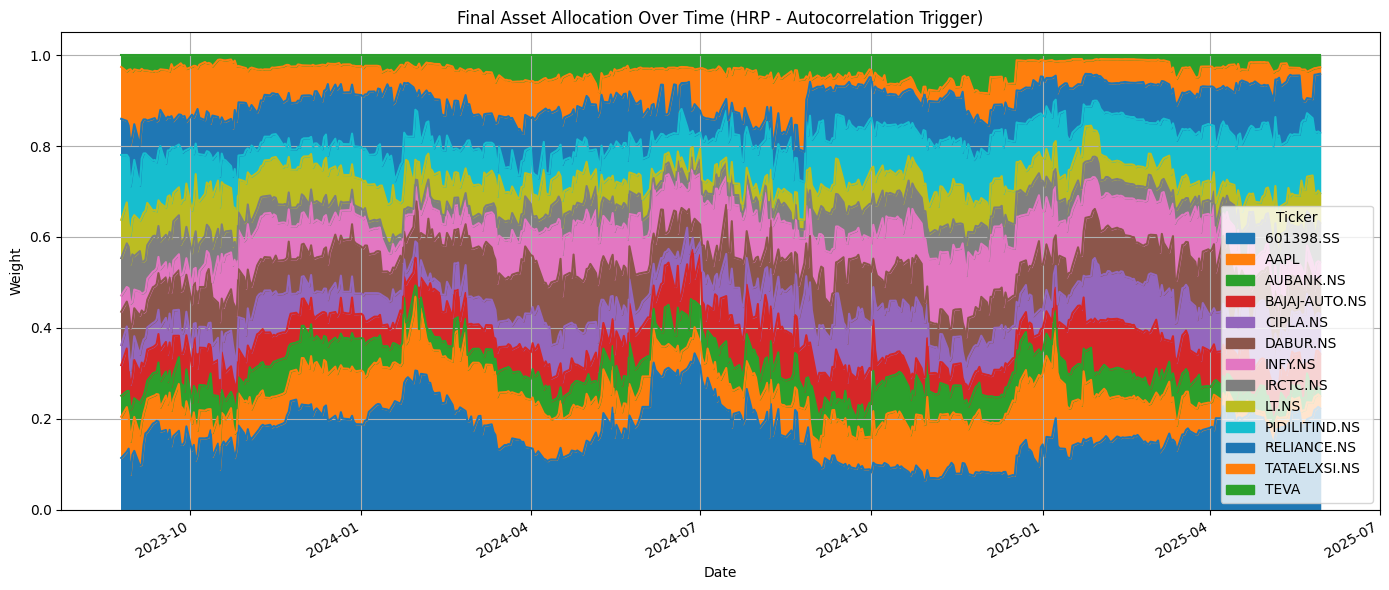

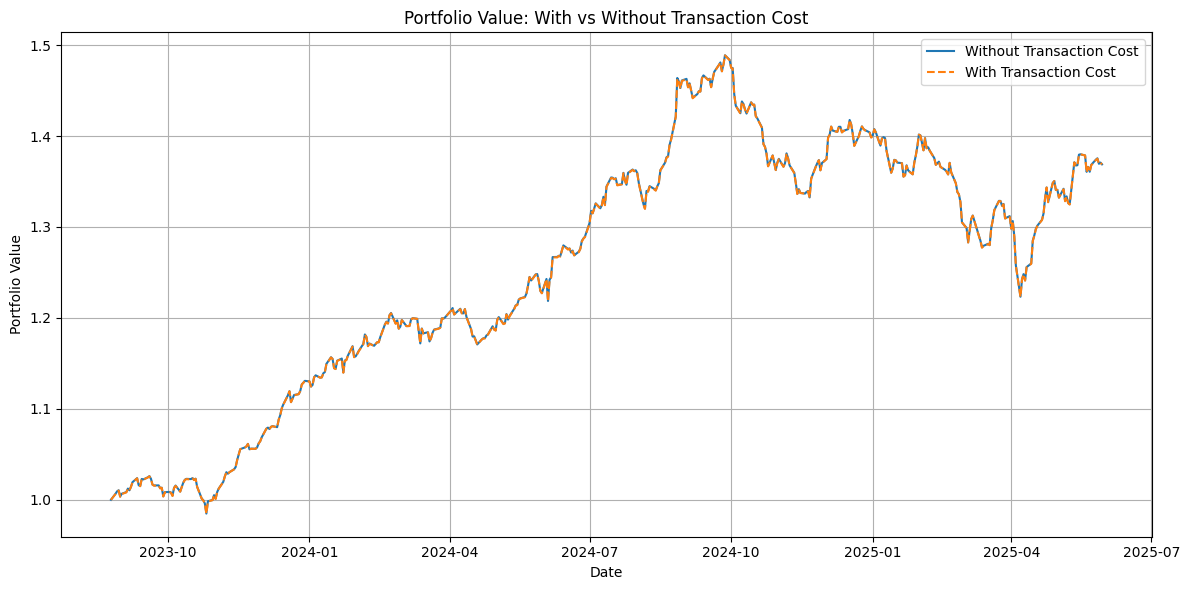

<ipython-input-2-1715228967>:146: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  equal_perf = (returns.loc[dates] * equal_df.shift().fillna(method='bfill')).sum(axis=1).add(1).cumprod()


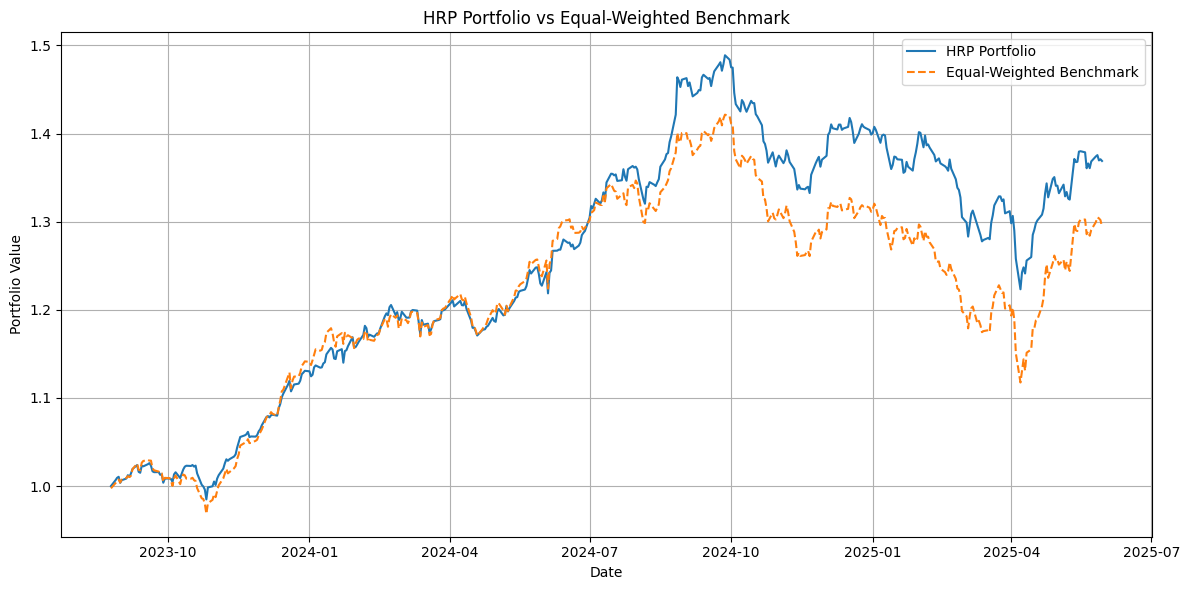

In [2]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import scipy.cluster.hierarchy as sch
from scipy.spatial.distance import squareform
import numpy as np

# 1.
startdate = '2023-06-01'
enddate = '2025-06-01'
tickers = ['RELIANCE.NS', 'INFY.NS','BAJAJ-AUTO.NS','DABUR.NS','CIPLA.NS','TATAELXSI.NS','PIDILITIND.NS','LT.NS','AUBANK.NS','IRCTC.NS','AAPL','TEVA','601398.SS']
df = yf.download(tickers, start=startdate, end=enddate)['Close']
#2.
returns = df.pct_change().dropna()
corrmatrix = returns.corr()
#3.
corrdistance = 1 - corrmatrix
condensedcorrdistance = squareform(corrdistance.values)
linkagematrix = sch.linkage(condensedcorrdistance, method='single')

plt.figure(figsize=(16, 7))
sch.dendrogram(linkagematrix, labels=corrmatrix.columns)
plt.title('Hierarchical Clustering Dendrogram (1 - Correlation)')
plt.xlabel('Stocks')
plt.ylabel('Distance')
plt.tight_layout()
plt.show()

#4.
def quasidiag(link):
    link = link.astype(int)
    sort = pd.Series([link[-1, 0], link[-1, 1]])
    numitems = link[-1, 3]
    while sort.max() >= numitems:
        sort.index = range(0, sort.shape[0]*2, 2)
        df0 = sort[sort >= numitems]
        i = df0.index
        j = df0.values - numitems
        sort[i] = link[j, 0]
        df1 = pd.Series(link[j, 1], index=i+1)
        sort = pd.concat([sort, df1])
        sort = sort.sort_index()
        sort.index = range(sort.shape[0])
    return sort.astype(int).tolist()

def ivp(cov):
    ivp = 1. / np.diag(cov)
    ivp /= ivp.sum()
    return ivp

def clustervar(cov, clusters):
    cov1 = cov.loc[clusters, clusters]
    w = ivp(cov1).reshape(-1, 1)
    return float(np.dot(w.T, np.dot(cov1, w)))

def hrpweights(cov, sort):
    w = pd.Series(1.0, index=sort)
    clusters = [sort]
    while clusters:
        clusters = [cluster[i:j] for cluster in clusters
                    for i, j in ((0, len(cluster)//2), (len(cluster)//2, len(cluster)))
                    if len(cluster) > 1]
        for cluster in clusters:
            if len(cluster) <= 1:
                continue
            cluster0 = cluster[:len(cluster)//2]
            cluster1 = cluster[len(cluster)//2:]
            var0 = clustervar(cov, cluster0)
            var1 = clustervar(cov, cluster1)
            alpha = 1 - var0 / (var0 + var1)
            w[cluster0] *= alpha
            w[cluster1] *= 1 - alpha
    return w / w.sum()

#5. and 6.
weights = []
equal_weights = []
window = 60
autowindow = 30
threshold = 0.3
tcost = 0.003
portfoliovalue = 1.0
withtc = []
withouttc = []
prevweights = pd.Series(0, index=returns.columns)

for end in range(window, len(returns)):
    recent_returns = returns.iloc[end - autowindow:end]
    autocorrs = recent_returns.apply(lambda x: x.autocorr(lag=1))

    if (autocorrs < threshold).any():
        window_returns = returns.iloc[end - window:end]
        corr = window_returns.corr()
        cov = window_returns.cov()
        dist = 1 - corr
        link = sch.linkage(squareform(dist.values), method='single')
        sort = quasidiag(link)
        tickerorder = corr.columns.tolist()
        sort = [i for i in sort if i < len(tickerorder)]
        sortedtickers = [tickerorder[i] for i in sort]
        hrpw = hrpweights(cov, sortedtickers)
        hrpw = hrpw.reindex(returns.columns).fillna(0)
    else:
        hrpw = prevweights

    weights.append(hrpw)
    equal_weights.append(pd.Series(1/len(returns.columns), index=returns.columns))

    ret = returns.iloc[end]
    grossreturn = np.dot(prevweights, ret)
    portfoliovalue *= (1 + grossreturn)
    withouttc.append(portfoliovalue)

    weightdiff = hrpw - prevweights
    sellcost = np.sum(np.abs(weightdiff[weightdiff < 0]) * tcost)
    portfolio_value_tc = portfoliovalue * (1 - sellcost)
    withtc.append(portfolio_value_tc)

    prevweights = hrpw

dates = returns.index[window:]
weights_df = pd.DataFrame(weights, index=dates)
equal_df = pd.DataFrame(equal_weights, index=dates)

#7.
weights_df.plot.area(figsize=(14, 6), title="Final Asset Allocation Over Time (HRP - Autocorrelation Trigger)")
plt.xlabel("Date")
plt.ylabel("Weight")
plt.tight_layout()
plt.grid(True)
plt.show()


plt.figure(figsize=(12,6))
plt.plot(dates, withouttc, label='Without Transaction Cost')
plt.plot(dates, withtc, label='With Transaction Cost', linestyle='--')
plt.title('Portfolio Value: With vs Without Transaction Cost')
plt.xlabel('Date')
plt.ylabel('Portfolio Value')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


equal_perf = (returns.loc[dates] * equal_df.shift().fillna(method='bfill')).sum(axis=1).add(1).cumprod()
hrp_perf = pd.Series(withouttc, index=dates)

plt.figure(figsize=(12,6))
plt.plot(dates, hrp_perf, label='HRP Portfolio')
plt.plot(dates, equal_perf, label='Equal-Weighted Benchmark', linestyle='--')
plt.title('HRP Portfolio vs Equal-Weighted Benchmark')
plt.xlabel('Date')
plt.ylabel('Portfolio Value')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
